# Test Decoder: Rotated Surface Code Memory Experiment

Memory experiment of rotated surface code with pymatching decoder.
LER vs PER (Physical Error Rate) for distances d = 3, 5, 7.

In [1]:
import sys
import os
import numpy as np

# Add project root to path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from experiments.memory import MemoryExperiment
from src.qec_code.surface_code.rotated import RotatedSurfaceCode, RotatedSurfaceCodeExtractionBlock
from src.qec_code.surface_code.toric import ToricCode, ToricCodeExtractionBlock
from src.ir.qec_system import QECSystem
from src.noise.config import NoiseConfig
from src.simulation.decoder_backend import SimulationPipeline, ExperimentTask, DecoderConfig
from src.plot import plot_ler_vs_p

In [2]:
# Parameters: short PER list and low max_errors for fast simulation
DISTANCES = [3, 5, 7]
PER_LIST = [1e-3, 2e-3, 5e-3, 1e-2]
MAX_ERRORS = 25
NUM_WORKERS = 5  # Single-thread for notebooks (multiprocessing can be tricky)

In [3]:
# Build tasks: for each (d, p) create a stim circuit and metadata
tasks = []
for d in DISTANCES:
    for p in PER_LIST:
        # Create rotated surface code and system
        surface_code = ToricCode(distance = d) # Rotated Surface Code
        system = QECSystem()
        system.add_patch(surface_code, name="rotated")
        
        # Noise params with uniform p for all error types
        noise_params = NoiseConfig(
            p_idle=p, p_meas=p, p_reset=p,
            p_1q=p, p_2q=p
        )
        
        # Build memory experiment circuit (suppress print)
        import io
        import contextlib
        with contextlib.redirect_stdout(io.StringIO()):
            mem_exp = MemoryExperiment(
                qec_system=system,
                extraction_block_class=ToricCodeExtractionBlock,
                rounds=d,
                noise_params=noise_params,
                noise_model='circuit_level',
                basis='Z',
            )
            circuit = mem_exp.build()
        
        tasks.append(ExperimentTask(circuit, json_metadata={"d": d, "p": p}))

print(f"Built {len(tasks)} tasks")

Built 12 tasks


In [4]:
# Run simulation with pymatching decoder
decoder_config = DecoderConfig("pymatching", backend="cpu")
pipeline = SimulationPipeline(
    decoder_config=decoder_config,
    max_errors=MAX_ERRORS,
    max_shots=1_000_000,
    num_workers=NUM_WORKERS,
    print_progress=True,
)

df = pipeline.run_batch(tasks)
df

Task 1/12: {'d': 3, 'p': 0.001}


Starting 5 workers...
1 tasks left:
  workers    decoder eta shots_left errors_left json_metadata
        5 pymatching <1m     983343           7 d=3,p=0.001  
1 tasks left:
  workers    decoder        eta shots_left errors_left json_metadata
        5 pymatching [draining]     942588         -43 d=3,p=0.001  
Starting 5 workers...


Task 2/12: {'d': 3, 'p': 0.002}


1 tasks left:
  workers    decoder        eta shots_left errors_left json_metadata
        5 pymatching [draining]     993583          -2 d=3,p=0.002  
1 tasks left:
  workers    decoder        eta shots_left errors_left json_metadata
        5 pymatching [draining]     992286          -7 d=3,p=0.002  
Starting 5 workers...


Task 3/12: {'d': 3, 'p': 0.005}


...

Task 11/12: {'d': 7, 'p': 0.005}


1 tasks left:
  workers    decoder eta shots_left errors_left json_metadata
        5 pymatching <1m     999727          24 d=7,p=0.005  
1 tasks left:
  workers    decoder        eta shots_left errors_left json_metadata
        5 pymatching [draining]     989419         -20 d=7,p=0.005  
Starting 5 workers...


Task 12/12: {'d': 7, 'p': 0.01}


1 tasks left:
  workers    decoder        eta shots_left errors_left json_metadata
        5 pymatching [draining]     999727         -22 d=7,p=0.01   
1 tasks left:
  workers    decoder        eta shots_left errors_left json_metadata
        5 pymatching [draining]     998635        -188 d=7,p=0.01   


,shots,post_selected_shots,post_selection_rate,errors,logical_error_rate,seconds,decoder,d,p
0,57412,57412,1.0,68,0.001184,0.033119,pymatching,3,0.001
1,7714,7714,1.0,32,0.004148,0.011913,pymatching,3,0.002
2,1297,1297,1.0,41,0.031611,0.003942,pymatching,3,0.005
3,273,273,1.0,31,0.113553,0.001769,pymatching,3,0.010
4,486741,486741,1.0,30,0.000062,1.152973,pymatching,5,0.001
5,76117,76117,1.0,35,0.000460,0.289258,pymatching,5,0.002
6,4915,4915,1.0,68,0.013835,0.056835,pymatching,5,0.005
7,564,564,1.0,84,0.148936,0.021567,pymatching,5,0.010
8,1000000,1000000,1.0,2,0.000002,5.686610,pymatching,7,0.001
9,473429,473429,1.0,32,0.000068,5.168273,pymatching,7,0.002


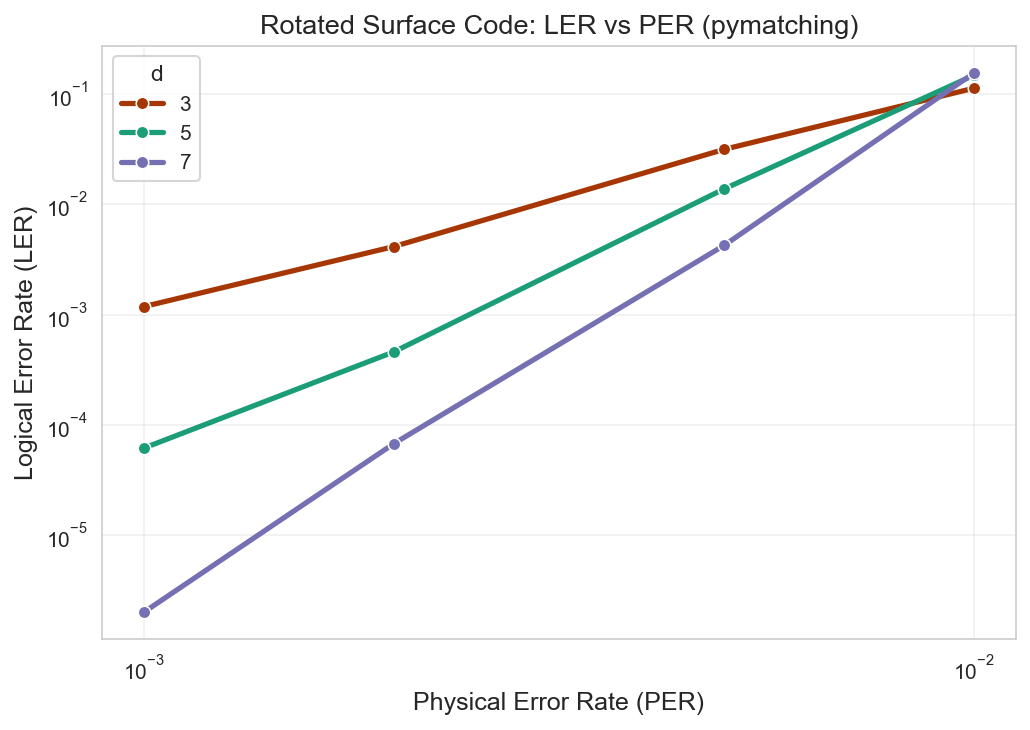

In [5]:
# Plot LER vs PER using our plot module
# Trailing ; suppresses duplicate display (plt.show already shows; Jupyter also displays returned fig)
plot_ler_vs_p(
    df,
    hue="d",
    x_col="p",
    x_label="Physical Error Rate (PER)",
    y_label="Logical Error Rate (LER)",
    title="Rotated Surface Code: LER vs PER (pymatching)"
);

## BB Code Memory Experiment

Memory experiment on BB (Bivariate Bicycle) code with l=6, m=6, A=[[3,0],[0,1],[0,2]], B=[[0,3],[1,0],[2,0]] using **bposd** decoder.
Requires: `pip install stimbposd` (or `pip install ldpc` as fallback).

In [6]:
# BB code parameters
BB_L, BB_M = 12, 6
BB_A = [[3, 0], [0, 1], [0, 2]]
BB_B = [[0, 3], [1, 0], [2, 0]]
BB_ROUNDS = 6  # rounds for memory experiment
BB_PER_LIST = [1e-3]  # BB codes are larger; use lower PER for reasonable LER
BB_MAX_ERRORS = 25

In [ ]:
# Build BB code tasks
from src.qec_code.BB_code import BBCode, BBCodeExtractionBlock

bb_tasks = []
for p in BB_PER_LIST:
    bb_code = BBCode(l=BB_L, m=BB_M, A=BB_A, B=BB_B, d=6)
    system = QECSystem()
    system.add_patch(bb_code, name="bb")
    noise_params = NoiseConfig(p_idle=p, p_meas=p, p_reset=p, p_1q=p, p_2q=p)
    import io, contextlib
    with contextlib.redirect_stdout(io.StringIO()):
        mem_exp = MemoryExperiment(
            qec_system=system,
            extraction_block_class=BBCodeExtractionBlock,
            rounds=BB_ROUNDS,
            noise_params=noise_params,
            noise_model='circuit_level',
            basis='Z',
        )
        circuit = mem_exp.build()
    bb_tasks.append(ExperimentTask(circuit, json_metadata={"p": p}))

print(f"Built {len(bb_tasks)} BB code tasks")

In [ ]:
# Run simulation with bposd decoder (requires: pip install stimbposd)
decoder_config = DecoderConfig("mwpf", backend="cpu")
bb_pipeline = SimulationPipeline(
    decoder_config=decoder_config,
    max_errors=BB_MAX_ERRORS,
    max_shots=1_000_000,
    num_workers=NUM_WORKERS,
    print_progress=True,
)

df_bb = bb_pipeline.run_batch(bb_tasks)
df_bb

Starting 5 workers...


Task 1/1: {'p': 0.001}


1 tasks left:
  workers decoder  eta shots_left errors_left json_metadata
        5    mwpf 412m     999999          25 p=0.001      
1 tasks left:
  workers decoder  eta shots_left errors_left json_metadata
        5    mwpf 204m     999995          25 p=0.001      
1 tasks left:
  workers decoder  eta shots_left errors_left json_metadata
        5    mwpf 109m     999978          25 p=0.001      
1 tasks left:
  workers decoder  eta shots_left errors_left json_metadata
        5    mwpf 123m     999970          25 p=0.001      
1 tasks left:
  workers decoder  eta shots_left errors_left json_metadata
        5    mwpf 125m     999954          25 p=0.001      
1 tasks left:
  workers decoder  eta shots_left errors_left json_metadata
        5    mwpf 147m     999937          25 p=0.001      
1 tasks left:
  workers decoder  eta shots_left errors_left json_metadata
        5    mwpf 170m     999920          25 p=0.001      
1 tasks left:
  workers decoder  eta shots_left errors_left js

,shots,post_selected_shots,post_selection_rate,errors,logical_error_rate,seconds,decoder,p
0,37035,37035,1.0,31,0.000837,2996.442132,mwpf,0.001


In [ ]:
# Plot BB code LER vs PER (single curve; hue=None for one line)
plot_ler_vs_p(
    df_bb,
    hue=None,
    x_col="p",
    x_label="Physical Error Rate (PER)",
    y_label="Logical Error Rate (LER)",
    title="BB Code [[72,12,6]]: LER vs PER (bposd)"
);